In [9]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Administrator\decision-intelligence-platform\data\raw\train.csv")

print(df.shape)
df.head()

(3000888, 6)


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [10]:
#Step 1 — Inspect the Data Properly
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


In [11]:
df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [12]:
df.describe()

,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


In [13]:
#Step 2 — Convert Date Column
df["date"] = pd.to_datetime(df["date"])

In [14]:
df.dtypes

id                      int64
date           datetime64[ns]
store_nbr               int64
family                 object
sales                 float64
onpromotion             int64
dtype: object

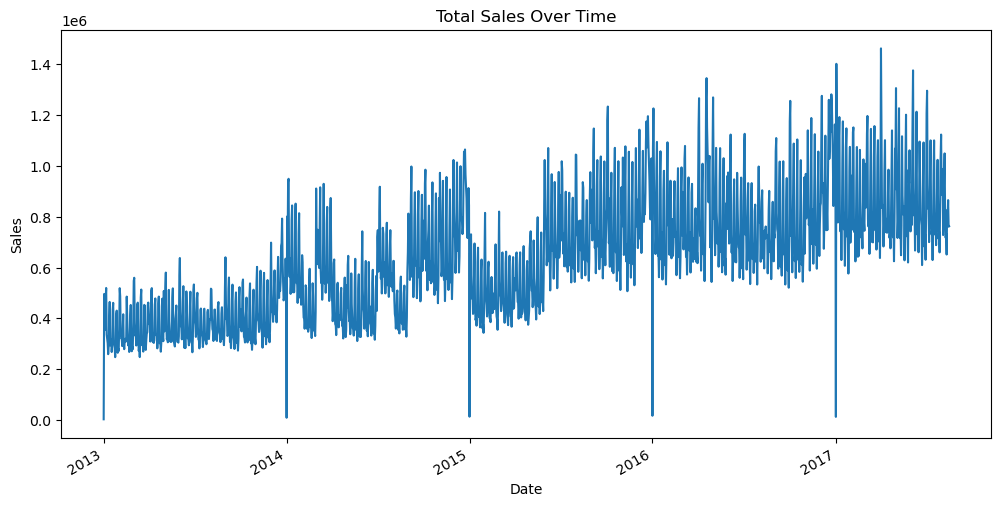

In [15]:
#Step 3 — Global Sales Trend
import matplotlib.pyplot as plt

daily_sales = df.groupby("date")["sales"].sum()

plt.figure(figsize=(12,6))
daily_sales.plot()
plt.title("Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [16]:
#Step 4 — Sales by Product Family
family_sales = df.groupby("family")["sales"].sum().sort_values(ascending=False)

family_sales.head(10)

family
GROCERY I        3.434627e+08
BEVERAGES        2.169545e+08
PRODUCE          1.227047e+08
CLEANING         9.752129e+07
DAIRY            6.448771e+07
BREAD/BAKERY     4.213395e+07
POULTRY          3.187600e+07
MEATS            3.108647e+07
PERSONAL CARE    2.459205e+07
DELI             2.411032e+07
Name: sales, dtype: float64

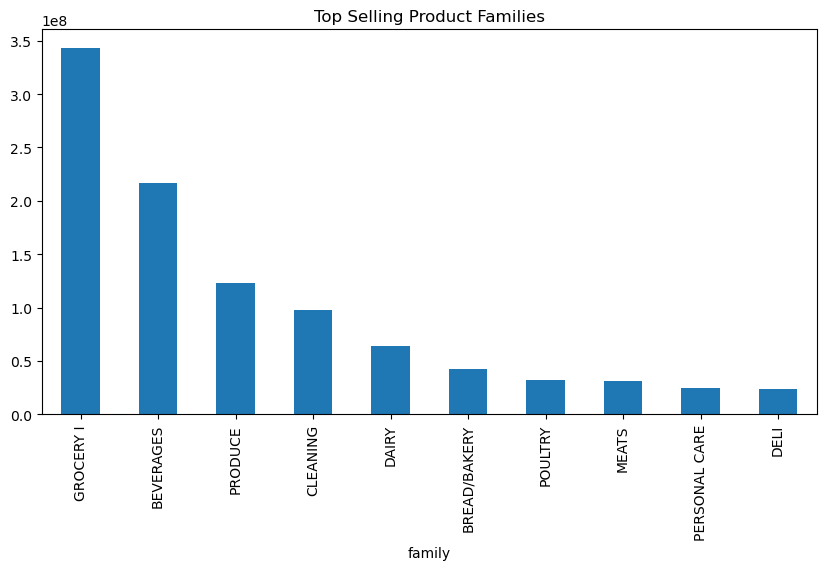

In [17]:
family_sales.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top Selling Product Families")
plt.show()

In [18]:
#Step 5 — Promotion Impact
promo_sales = df.groupby("onpromotion")["sales"].mean()

promo_sales

onpromotion
0       158.246681
1       467.556532
2       662.925632
3       871.408092
4       969.916135
          ...     
719    6681.000000
720    6154.000000
722    5846.000000
726    6044.000000
741    7517.000000
Name: sales, Length: 362, dtype: float64

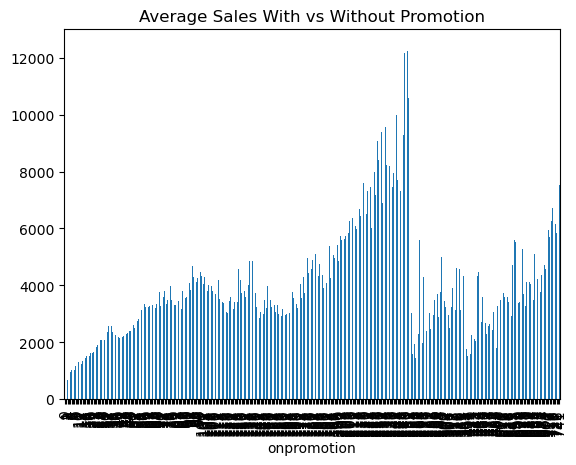

In [19]:
promo_sales.plot(kind="bar")
plt.title("Average Sales With vs Without Promotion")
plt.show()

In [20]:
#Step 6 — Sales by Store
store_sales = df.groupby("store_nbr")["sales"].sum()

store_sales.sort_values(ascending=False).head()

store_nbr
44    6.208755e+07
45    5.449801e+07
47    5.094831e+07
3     5.048191e+07
49    4.342010e+07
Name: sales, dtype: float64

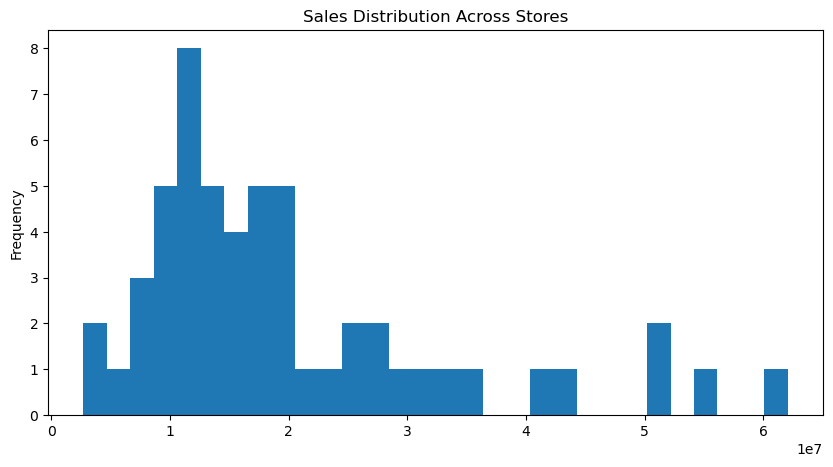

In [21]:
store_sales.plot(kind="hist", bins=30, figsize=(10,5))
plt.title("Sales Distribution Across Stores")
plt.show()